<a href="https://www.kaggle.com/code/kidusassefamebrate/salary-prediction-with-linear-regression?scriptVersionId=289676574" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv


### 1. Data Overview

In [2]:
sa_df = pd.read_csv('/kaggle/input/salary-dataset-simple-linear-regression/Salary_dataset.csv')

In [3]:
sa_df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [4]:
sa_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [5]:
sa_df.columns

Index(['Unnamed: 0', 'YearsExperience', 'Salary'], dtype='object')

In [6]:
sa_df = sa_df.drop(columns=['Unnamed: 0'])

In [7]:
sa_df.tail()

,YearsExperience,Salary
25,9.1,105583.0
26,9.6,116970.0
27,9.7,112636.0
28,10.4,122392.0
29,10.6,121873.0


### 2. Data Visualization

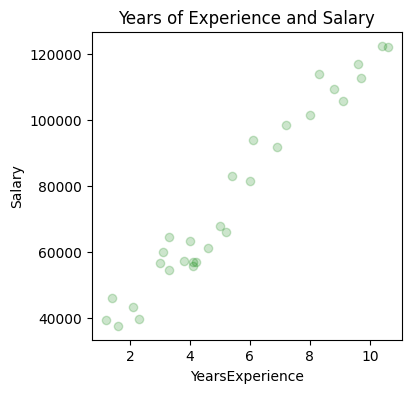

In [8]:
plt.figure(figsize=(4,4))
plt.scatter(sa_df['YearsExperience'], sa_df['Salary'], alpha = 0.2, color = 'green')
plt.title('Years of Experience and Salary')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [9]:
sa_df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


### 3. Linear Regression

In [10]:
X= sa_df[['YearsExperience']]
y= sa_df['Salary']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [12]:
X_train.shape

(24, 1)

In [13]:
y_train.shape

(24,)

In [14]:
lin_reg = LinearRegression()

In [15]:
lin_reg.fit(X_train, y_train)

LinearRegression()

In [16]:
lin_reg.score(X_test, y_test)

0.9024461774180497

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


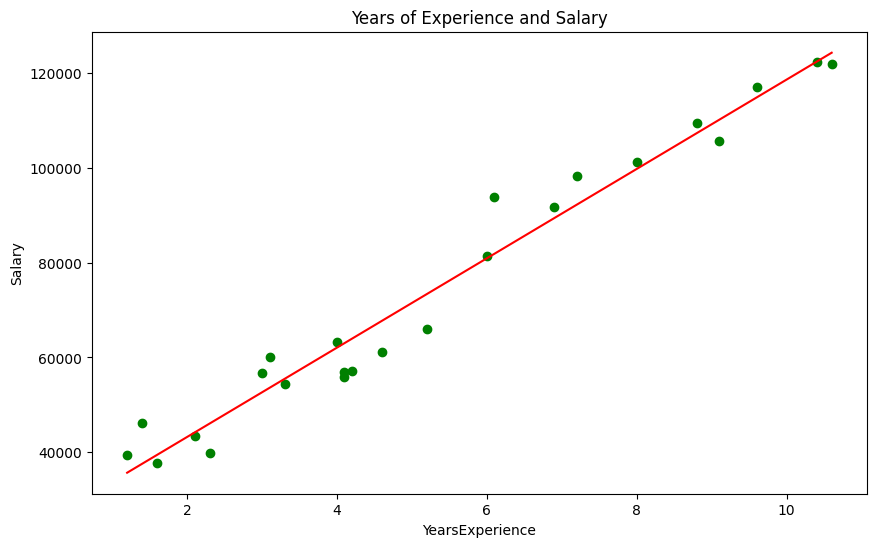

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='green')
x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)
plt.plot(x_line, y_line, color='red')
plt.title('Years of Experience and Salary')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()